# 11.15 筆畫已被縮掉，較大的模型能確定補回嗎？


「未」和「末」有很小的筆畫差異；若縮圖把差異合在一起，後面的模型只收到縮完的數字。先用一條一像素寬亮線，單獨看縮小到底留下什麼。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

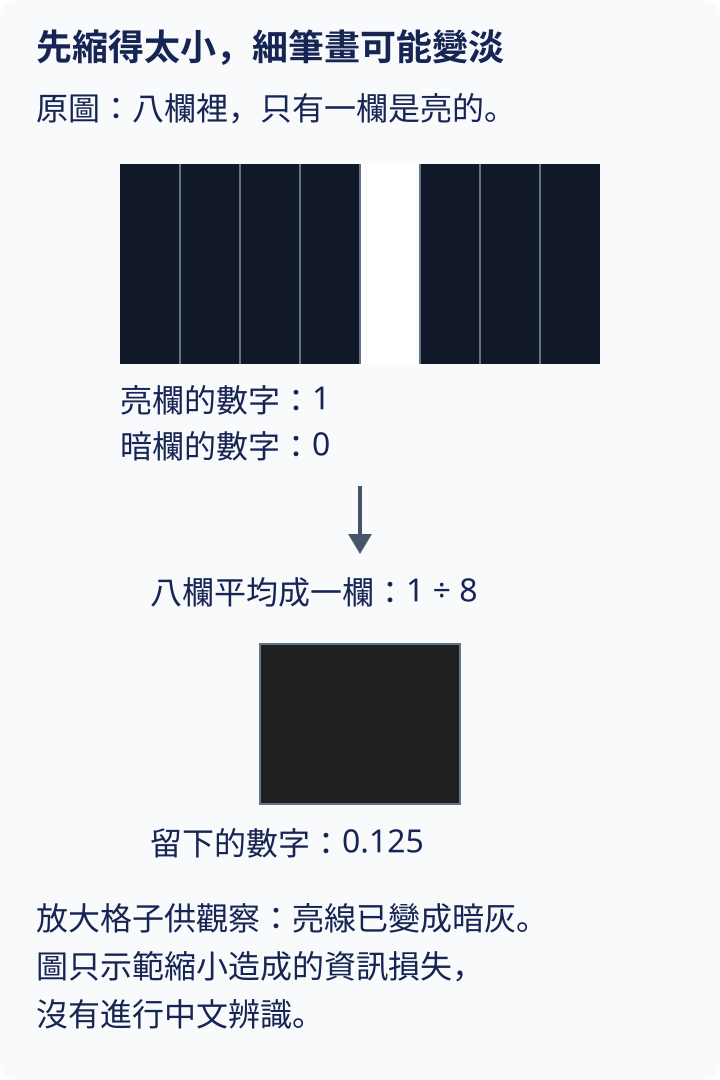

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/practical_stroke.svg")))

In [3]:
from tiny_perceptron.natural_concepts import thin_stroke_report

report = thin_stroke_report()
print("原圖與縮圖尺寸", report["original_shape"], report["small_shape"])
print("最亮的數字", report["original_brightest"], report["small_brightest"])
print("至少半亮的數字個數", report["pixels_at_least_half_bright_before"], report["pixels_at_least_half_bright_after"])

原圖與縮圖尺寸 [32, 32] [4, 4]
最亮的數字 1.0 0.125
至少半亮的數字個數 32 0


原圖 32×32，整欄 32 點設 1，再將每 8×8 平均成一格，得到 4×4。八欄只有一欄亮，因此最高從 1 成 1/8＝0.125；至少 0.5 的格數從 32 成 0。

0.5 是讓變化可見的手設門檻，不是 OCR 必然判準；這個計算沒有測認字。它說明前處理會改變模型可用的證據。更大文字模型可能憑語境猜字，卻無法可靠從相同模糊數字還原不同原筆畫。

可以保留較高解析度，或裁小窗放大讀，同時保留小窗在原圖的位置。這裡的圖片特徵位置，是共同序列中每一小塊圖所佔的位置，不是原圖的坐標。如果每塊的像素大小不變，保留更大圖片或增加小窗就需要處理更多塊，序列會更長、計算量也會增加，詳見[11.10的位置與成本](https://birdhackor.github.io/tiny-perceptron-vlm/11.10.html)。原圖本就模糊或遮住，也應允許看不清，而不強迫補詞。

主線有限中文字任務還需要教字形與正確答案，數字字形訓練不能代替中文材料。練習分別說明「放大生成模型」「保留像素細節」「補字形示範」各解決哪一段；別把三個選擇當作相同方法。

<details>
<summary>回顧與查證</summary>

可回顧：[11.9縮圖與裁切](https://birdhackor.github.io/tiny-perceptron-vlm/11.9.html)、[11.12讀字任務](https://birdhackor.github.io/tiny-perceptron-vlm/11.12.html)。

第20章沿用既有圖文底座，是另一條延伸；當前保留原底座而未啟用微調修正，不用它的能力替代這個自訓練任務。

</details>
